<a href="https://colab.research.google.com/github/ashishthomaschempolil/Medical-Image-Captioning-on-Chest-X-rays/blob/main/EDA_Medical_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wordcloud
!pip install tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import cv2
from google.colab.patches import cv2_imshow
import re
from bs4 import BeautifulSoup #for reading xml file
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS  #for plotting wordcloud
from tqdm import tqdm

# **Exploratory Data Analysis**

## **Images**

In [ ]:
image_folder = '/content/drive/MyDrive/Radiography/images' #path to folder containing images
total_images = len(os.listdir(image_folder))
print('The number of images in data are: %i'%(total_images))

The number of images in data are: 7491


1)



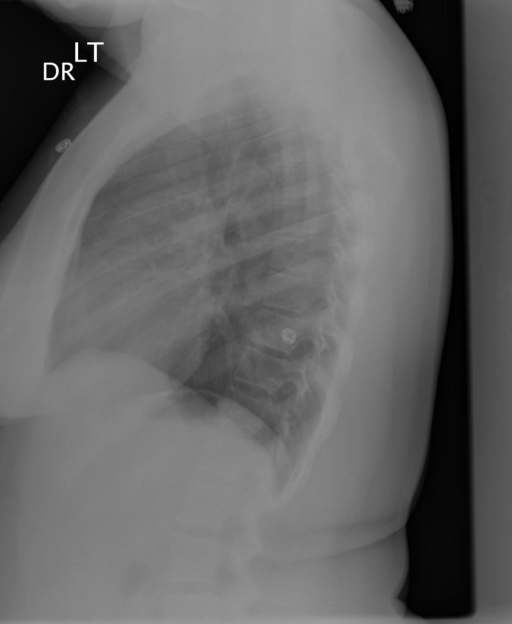

		 CXR1712_IM-0470-2001.png
2)



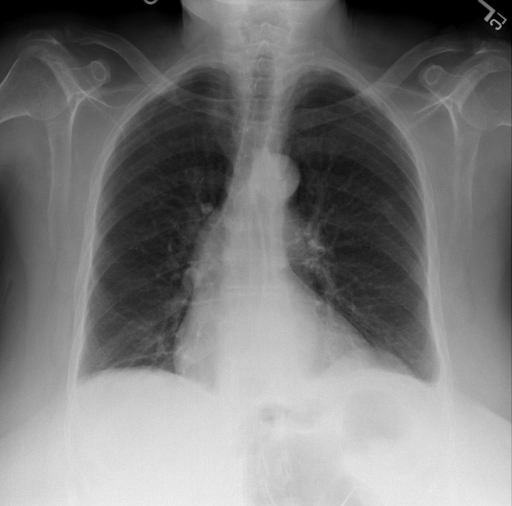

		 CXR2102_IM-0733-1001.png
3)



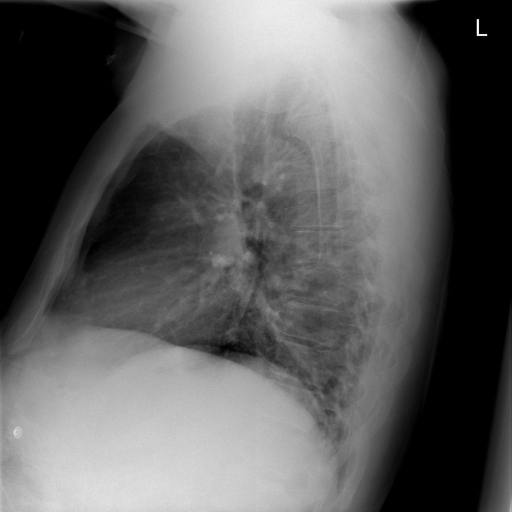

		 CXR304_IM-1413-2001.png


In [ ]:
#showing random 3 sample images
np.random.seed(420)
for i in range(3): #print 3 sample images
  k = np.random.choice(range(total_images))
  image_file = os.listdir(image_folder)[k]
  image = cv2.imread(os.path.join(image_folder,image_file)) #getting an image file
  print("%i)\n"%(i+1))
  cv2_imshow(image)
  print("\t\t",image_file) #the image file name

We can see 3 sample images of the dataset. These are chest X_rays which are taken in  front and side view.

## **Reports**

In [ ]:
reports_folder = "/content/drive/MyDrive/Radiography/report"
total_reports = len(os.listdir(reports_folder))
print('The number of reports in the data are: %i'%(total_reports))

The number of reports in the data are: 3955


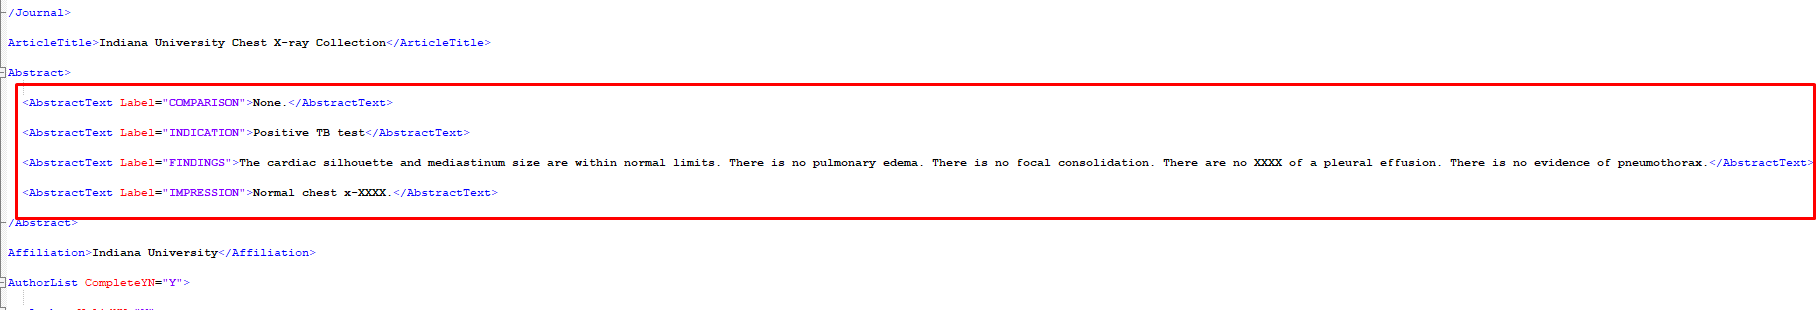

In the xml file, report information is stored like this.

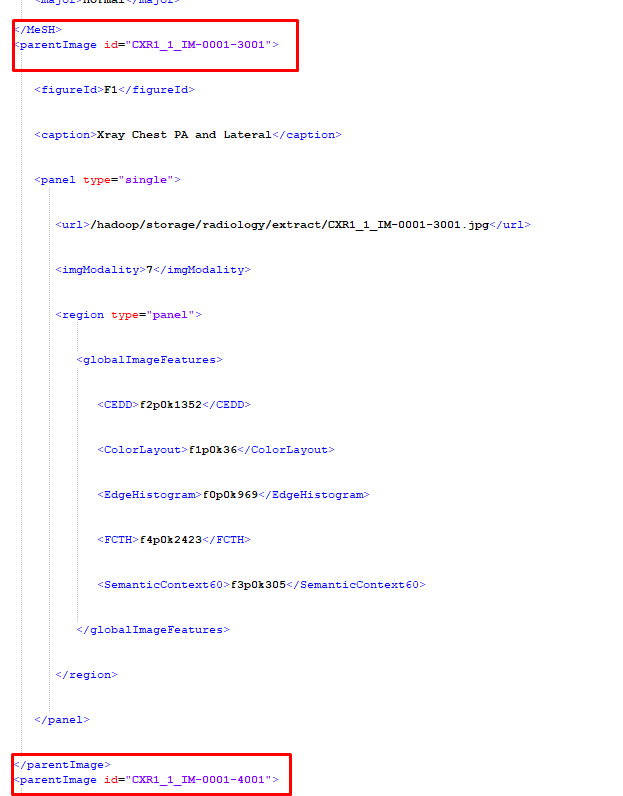

These are the two image files that are associated with this report.
Now we will see what is the maximum and minimum possible value for number of images that are associated with a report.

In [ ]:
no_images = [] #stores the no. of images
for file in os.listdir(reports_folder):
  report_file = os.path.join(reports_folder,file)
  with open(report_file, 'r') as f:  #reading the xml data
    data = f.read()
  regex = r"parentImage id.*" #getting all the image names
  k  = re.findall(regex,data)
  temp = len(k)
  no_images.append(temp)

In [ ]:
no_images = np.array(no_images)
print("The max no. of images found associated with a report: %i"%(no_images.max()))
print("The min no. of images found associated with a report: %i"%(no_images.min()))

The max no. of images found associated with a report: 5
The min no. of images found associated with a report: 0


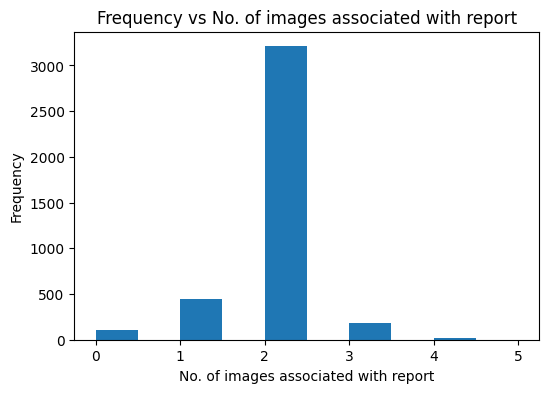

Image Value_counts

2    3208
1     446
3     181
0     104
4      15
5       1
Name: count, dtype: int64


In [ ]:
plt.figure(figsize = (6,4))
ax = pd.Series(no_images).plot(kind='hist')
ax.set_xlabel('No. of images associated with report')
ax.set_title("Frequency vs No. of images associated with report")
plt.show()
print("Image Value_counts\n")
print(pd.Series(no_images).value_counts())

From the information we can observe that one report can have maximum 5 references to images and minimum
0.i will extract all information part ie comparison, indication, findings and impression part of the report and the concerning 2 images (i will take 2 images as input as 2 images are highest frequecy of being associated with a report) of the concerned report to a dataframe with xml report file name.For more than 2 images we will creat new datapoint with new image and same info

In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd
import re
from pathlib import Path
from tqdm import tqdm

def decontract(phrase):
    """Perform text decontraction of words like won't to will not"""
    contractions = {
        "won't": "will not", "can't": "can not", "n't": " not",
        "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
        "'t": " not", "'ve": " have", "'m": " am"
    }
    for contraction, expansion in contractions.items():
        phrase = re.sub(rf"\b{contraction}\b", expansion, phrase)
    return phrase

def preprocess_text(text):
    """Preprocess the text by removing unwanted characters and decontracting"""
    if not text:
        return None

    # Remove numbers at the start of sentences and 'XXXX'
    text = re.sub(r'\d+\.|\bX+\b', '', text)

    # Remove special characters except periods
    text = re.sub(r'[^a-zA-Z\s.]', '', text)

    # Add space before periods and remove extra spaces
    text = re.sub(r'\s*\.\s*', ' . ', text)

    # Decontract words
    text = decontract(text)

    # Convert to lowercase and strip
    text = text.lower().strip()

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text if text else None

def parse_report(file_path):
    """Parse a single XML report file"""
    tree = ET.parse(file_path)
    root = tree.getroot()

    # Extract image names
    images = [img.attrib['id'] + '.png' for img in root.findall('.//parentImage')]

    data = {
        'image_1': images[0] if images else None,
        'image_2': images[1] if len(images) > 1 else None,
        'xml file name': file_path.name
    }

    # Extract and preprocess text sections
    for section in ['COMPARISON', 'INDICATION', 'FINDINGS', 'IMPRESSION']:
        elem = root.find(f".//AbstractText[@Label='{section}']")
        data[section.lower()] = preprocess_text(elem.text if elem is not None else None)

    return data

def get_df(reports_folder):
    """Process all XML files in the reports folder and return a DataFrame"""
    report_files = list(Path(reports_folder).glob('*.xml'))
    df = pd.DataFrame(map(parse_report, tqdm(report_files, desc="Processing reports")))
    return df



In [ ]:
%%time
df = get_df(reports_folder)

Processing reports: 100%|██████████| 3955/3955 [00:08<00:00, 493.05it/s]

CPU times: user 1.7 s, sys: 398 ms, total: 2.1 s
Wall time: 8.1 s


In [ ]:
df.to_pickle("/content/drive/MyDrive/Radiography/df1.pkl")
df = pd.read_pickle("//content/drive/MyDrive/Radiography/df1.pkl")
df.shape

(3955, 7)

In [ ]:
df.head()

,image_1,image_2,xml file name,comparison,indication,findings,impression
0,CXR3745_IM-1872-1001.png,CXR3745_IM-1872-1002.png,3745.xml,none,vehicle collision,cardiomediastinal silhouette and pulmonary vas...,no acute cardiopulmonary findings .
1,CXR3749_IM-1874-1001.png,CXR3749_IM-1874-2001.png,3749.xml,chest radiograph from .,chest pain .,lungs are clear bilaterally . cardiac and medi...,no acute cardiopulmonary abnormality .
2,CXR3738_IM-1867-1001.png,CXR3738_IM-1867-2001.png,3738.xml,None,yearold female with shortness of breath,the heart size and mediastinal contours appear...,no acute cardiopulmonary findings .
3,CXR3714_IM-1856-1001.png,CXR3714_IM-1856-2001.png,3714.xml,None,pain .,cardio mediastinal silhouette pulmonary vascul...,no acute cardiopulmonary disease .
4,CXR3716_IM-1856-1001.png,CXR3716_IM-1856-2001.png,3716.xml,none .,yearold male . vehicle accident .,the cardiomediastinal silhouette is normal in ...,negative for acute abnormality .


Now we check for missing values.

In [ ]:
print("columns\t\t%missing values")
print('-'*30)
print(df.isnull().sum()*100/df.shape[0] )#percentage missing values

columns		%missing values
------------------------------
image_1           2.629583
image_2          13.906448
xml file name     0.000000
comparison       27.560051
indication        6.194690
findings         13.400759
impression        0.859671
dtype: float64


In [ ]:
df.drop(df[(df['impression'].isnull())|(df['image_1'].isnull())].index,inplace=True)
df = df.reset_index(drop=True).copy()
print("%i datapoints were removed.\nFinal no. of datapoints: %i"%(4169-df.shape[0],df.shape[0]))

349 datapoints were removed.
Final no. of datapoints: 3820


There are missing values in image_2. For that we can use the same image file in image_1. We will also check for image size for both of them.

In [ ]:
%%time
df.loc[df.image_2.isnull(),'image_2'] = df[df.image_2.isnull()]['image_1'].values
im1_size = []
im2_size = []
for index,row in df.iterrows():
  im1_size.append( cv2.imread(os.path.join(image_folder,row.get('image_1'))).shape[:2])
  im2_size.append(cv2.imread(os.path.join(image_folder,row.get('image_2'))).shape[:2])

CPU times: user 25.7 s, sys: 2.02 s, total: 27.7 s
Wall time: 56.3 s


In [ ]:
df['im1_height'] = [i[0] for i in im1_size]
df['im1_width'] = [i[1] for i in im1_size]
df['im2_height'] = [i[0] for i in im2_size]
df['im2_width'] = [i[1] for i in im2_size]

In [ ]:
df.head(2)

,image_1,image_2,xml file name,comparison,indication,findings,impression,im1_height,im1_width,im2_height,im2_width
0,CXR3745_IM-1872-1001.png,CXR3745_IM-1872-1002.png,3745.xml,none,vehicle collision,cardiomediastinal silhouette and pulmonary vas...,no acute cardiopulmonary findings .,517,512,514,512
1,CXR3749_IM-1874-1001.png,CXR3749_IM-1874-2001.png,3749.xml,chest radiograph from .,chest pain .,lungs are clear bilaterally . cardiac and medi...,no acute cardiopulmonary abnormality .,420,512,624,512


In [ ]:
df.to_pickle("/content/drive/MyDrive/Radiography/df_final.pkl")
df = pd.read_pickle("/content/drive/MyDrive/Radiography/df_final.pkl")
df.shape

(3820, 11)

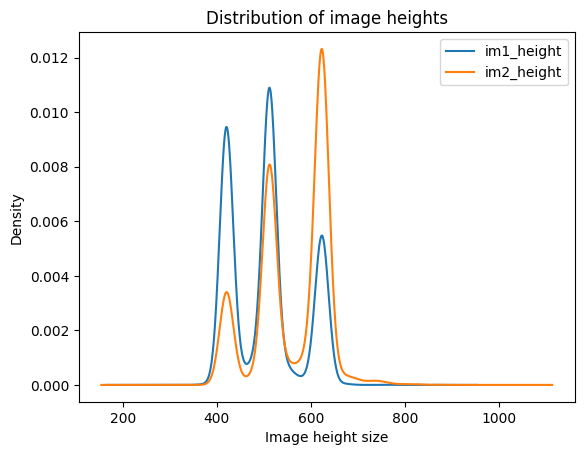



Value Counts of image_1 heights:

im1_height
420    1087
512     898
624     598
511     225
618      78
Name: count, dtype: int64

 ************************************************** 

Value Counts of image_2 heights:

im2_height
624    1396
512     691
420     380
511     210
618      82
Name: count, dtype: int64


In [ ]:
ax = df[['im1_height','im2_height']].plot(kind='kde')
ax.set_title("Distribution of image heights")
ax.set_xlabel("Image height size")
plt.show()

print("\n\nValue Counts of image_1 heights:\n")
print(df.im1_height.value_counts()[:5])
print("\n","*"*50,"\n")
print("Value Counts of image_2 heights:\n")
print(df.im2_height.value_counts()[:5])

We can observe that 420 is the most common height for image_1 while for image_2 is 624. The next common for both of the images is 512.

In [ ]:
print("Value Counts of image_1 widths:\n")
print(df.im1_width.value_counts()[:5])
print("\n","*"*50,"\n")
print("Value Counts of image_2 widths:\n")
print(df.im2_width.value_counts()[:5])

Value Counts of image_1 widths:

im1_width
512    3820
Name: count, dtype: int64

 ************************************************** 

Value Counts of image_2 widths:

im2_width
512    3820
Name: count, dtype: int64


Width for both of the images have only 1 unique value for all datapoints and that is 512. Since pretrained models are modelled for square-sized images we can choose 512\*512 as the specified size of the image. Hence we can resize all images into 512\*512 shape.

We'll print some sample datapoints with images and captions.

## **Sample Images + Caption**

In [ ]:
def show_image_captions(df = df,image_folder = image_folder,sample = 3):
  """
  given the df, samples datapoints and prints the images and caption
  df: dataframe
  image_folder: folder which contains images
  """
  k = df.sample(sample)
  i=1
  for index,row in k.iterrows():
    image_1 = cv2.imread(os.path.join(image_folder,row.get('image_1')))
    image_2 = cv2.imread(os.path.join(image_folder,row.get('image_2')))

    plt.figure(figsize = (12,8)) #setting the figure size
    plt.subplot(121) #first x-ray
    plt.imshow(image_1,aspect='auto')

    plt.subplot(122) #2nd x-ray
    plt.imshow(image_2, aspect = 'auto')
    print("%i)\n"%(i))
    i+=1
    plt.show() #printing the image
    print("\n","Comparison: ",row.get('comparison'))
    print("\n","Indication: ",row.get('indication'))
    print("\n","Findings: ",row.get('findings'))
    print("\n","Impression: ",row.get('impression'),"\n\n","*"*150,"\n\n")

1)



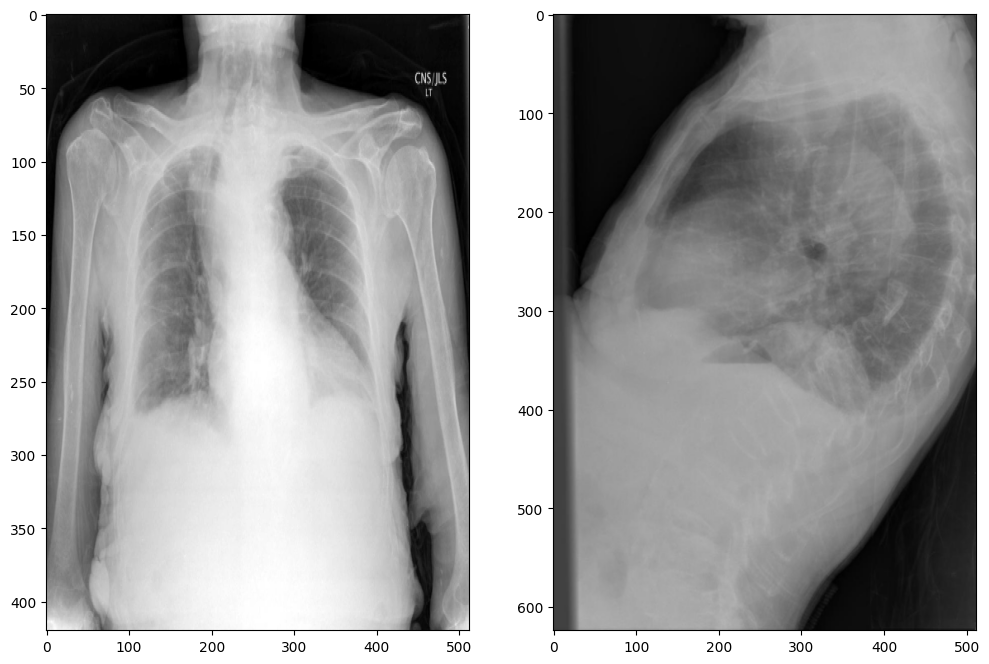


 Comparison:  chest x on

 Indication:  yearold female with chest pain persistent vomiting .

 Findings:  low lung volumes . stable ectasia of the thoracic aorta . stable right upper mediastinal bilateral small pleural effusions and bibasilar airspace opacities . the heart size and mediastinal silhouette are within normal limits for contour . no pneumothorax . stable wedging of the anterior thoracic vertebral bodies .

 Impression:  bilateral small pleural effusions and associated atelectasis . stable right upper mediastinal opacity consistent with goiter . 

 ****************************************************************************************************************************************************** 


2)



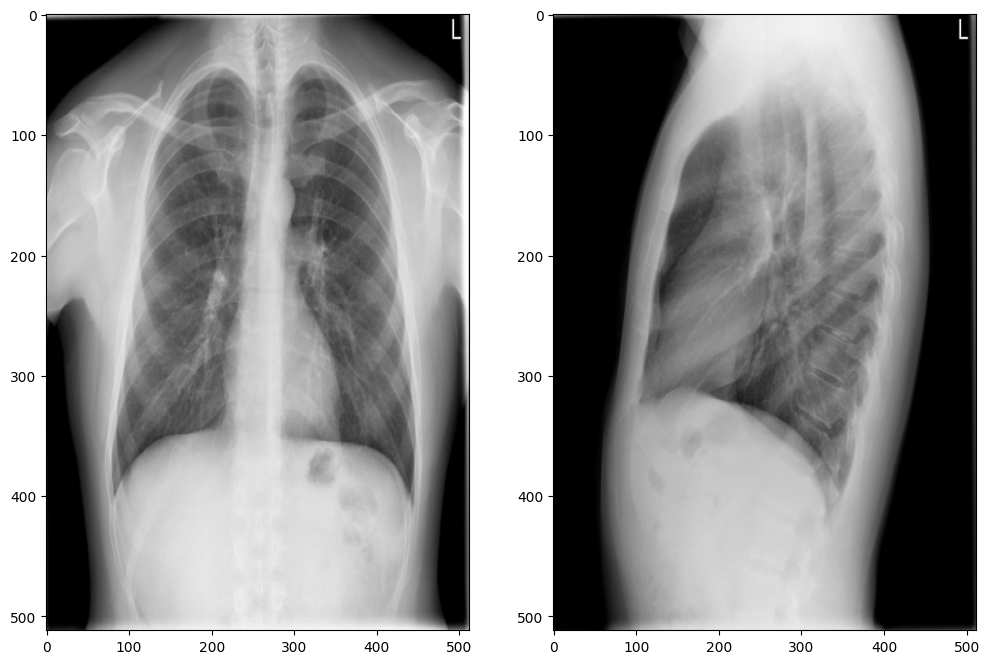


 Comparison:  none

 Indication:  testicular carcinoma

 Findings:  the heart size and pulmonary vascularity appear within normal limits . the lungs are free of focal airspace disease . no pleural effusion or pneumothorax is seen . no discrete nodules or adenopathy identified .

 Impression:  no evidence of active disease . 

 ****************************************************************************************************************************************************** 


3)



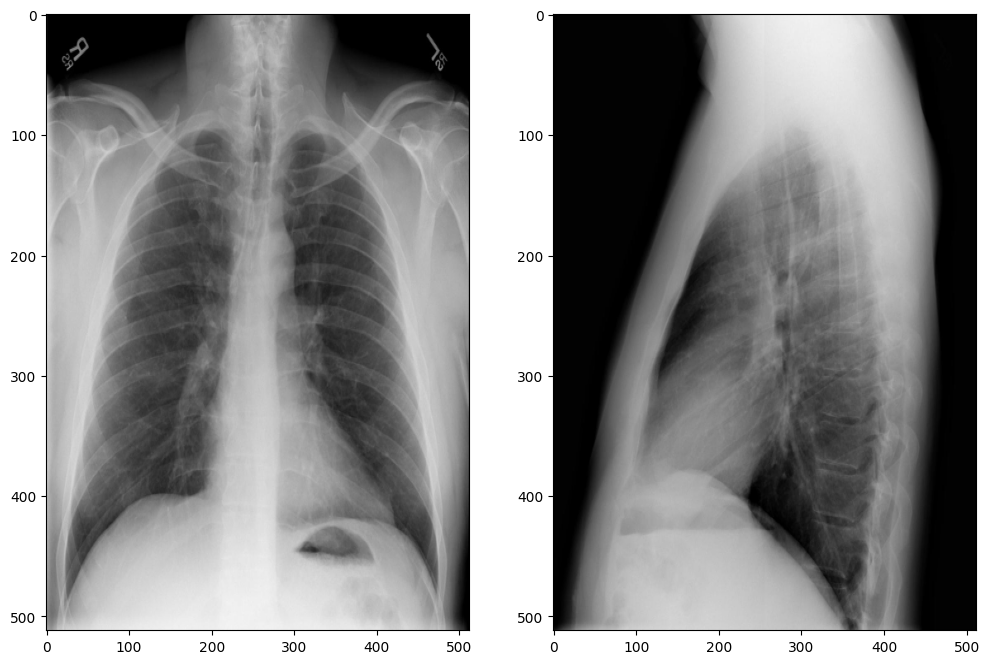


 Comparison:  none .

 Indication:  sensation of food in throat . choking sensation .

 Findings:  images . heart size and pulmonary vascular engorgement appear within limits of normal . mediastinal contour is unremarkable . no focal consolidation pleural effusion or pneumothorax identified . no convincing acute bony findings .

 Impression:  no acute cardiopulmonary abnormality identified . 

 ****************************************************************************************************************************************************** 




In [ ]:
#showing sample 3 datapoints
show_image_captions()

We can see that indications are patients medical complaints while findings are the obervations from X-ray while impression is inference obtained. In this case study, I will try to predict the impression part of the medical report given the two images.

### **Wordcloud of Impressions**

In [ ]:
#getting wordclouds
#https://www.geeksforgeeks.org/generating-word-cloud-python/
temp = df.loc[:,'impression'].str.replace(".","").copy() #removing all fullstops and storing the result in a temp variable
words = ""
for i in temp.values:
  k = i.split()
  words+= " ".join(k) + " "
word = words.strip()
wc = WordCloud(width = 1024, height = 720,
                background_color ='white',
                stopwords = STOPWORDS,
                min_font_size = 15,).generate(words)

del k,words,temp

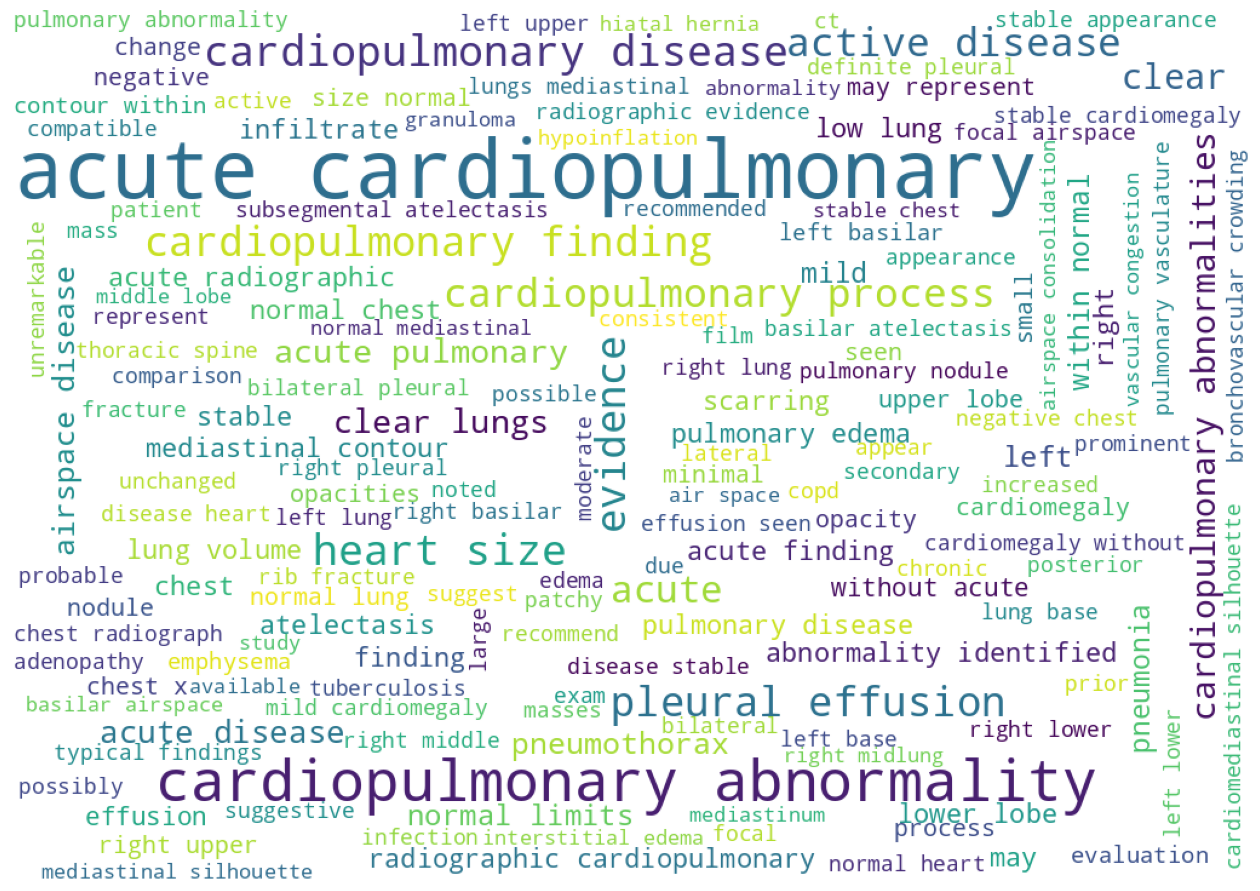

In [ ]:
plt.figure(figsize = (16,16))
plt.imshow(wc)
plt.axis("off")
plt.show()

From the word cloud, we can see that the moist common and opopular words in the  data are acute, cardiopulmonary, abnomality